# Dataset description
## Exports vs. Imports

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-trimestrales/historicos-producto-interno-bruto-pib)

# Code
## Imports

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [88]:
path = "./data/gdp.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [89]:
df = df[
    (df["Concepto"] == "Exportaciones") |
    (df["Concepto"] == "Importaciones")
]

df.columns = (
    df.columns
    .str.split("-")
    .str[0]
    .str.replace(r"[pr]+$", "", regex=True)
)
df.set_index("Concepto", inplace=True)
df.index.name = None
df_f = df.T

total = df_f.groupby(df_f.index).sum()
total.drop(total.index[-1], inplace=True) # removing 2026 since it is incomplete

## plot

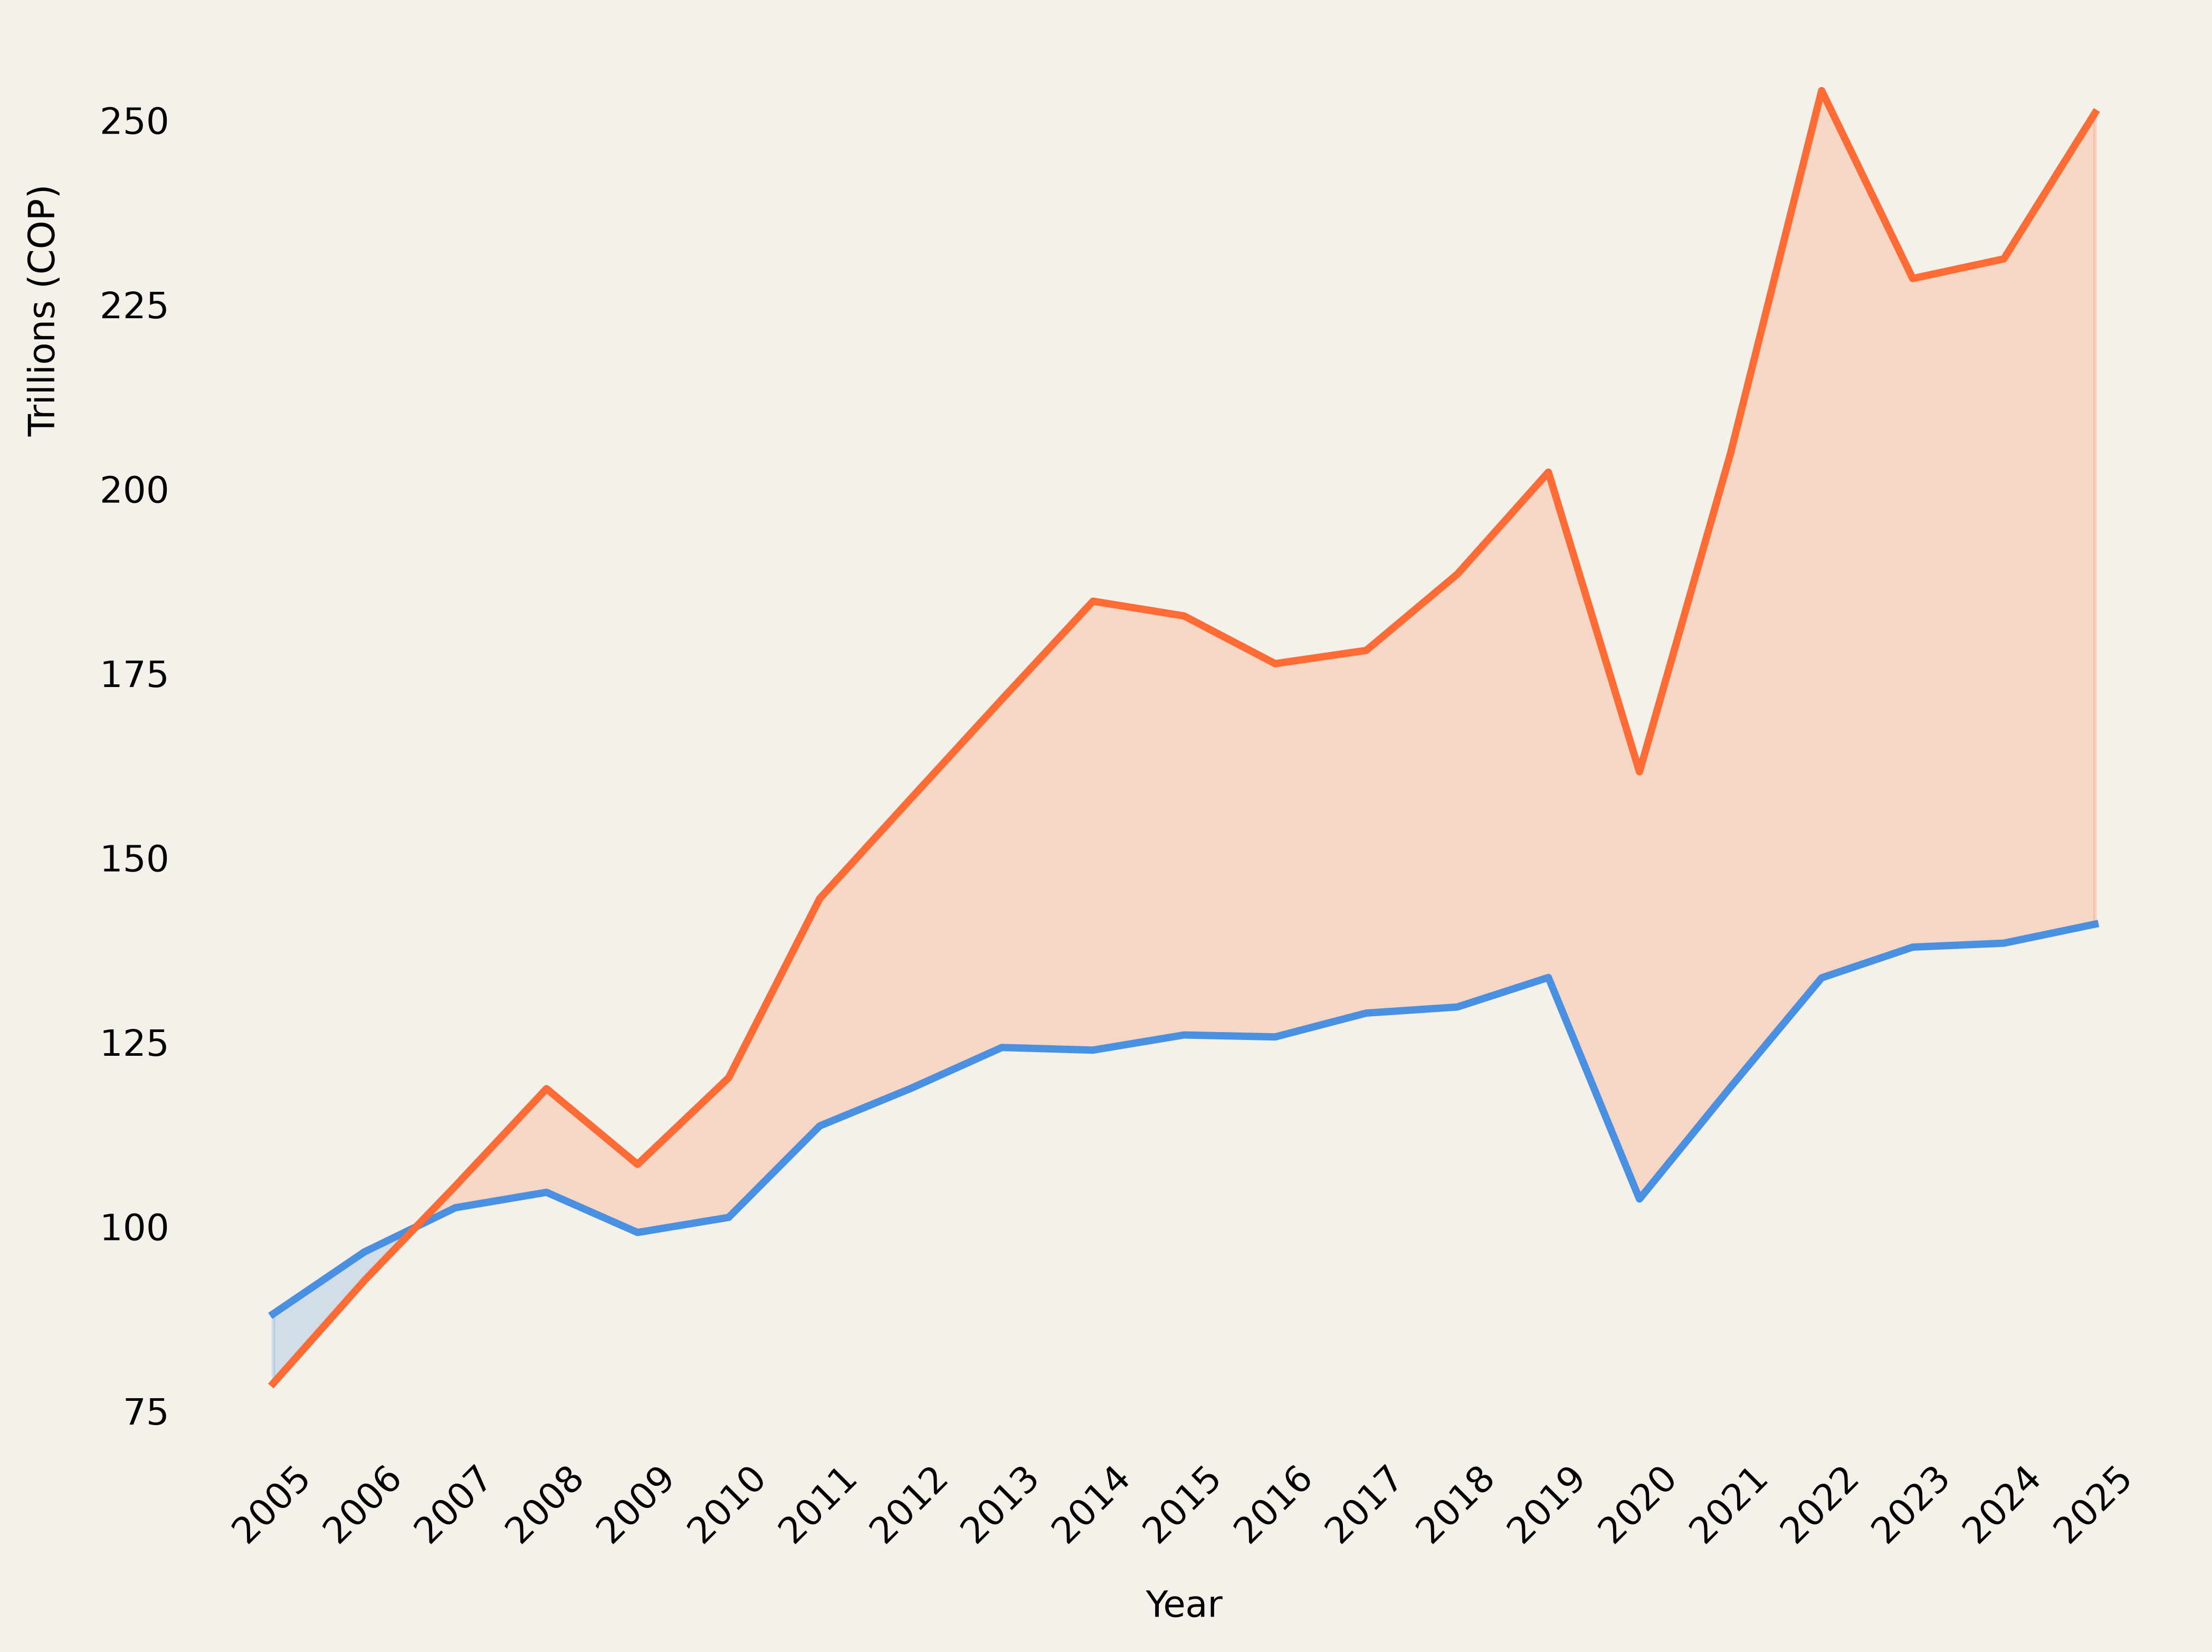

In [100]:
background = "#F4F1EA"
blue = "#4a90e2"
orange = "#FF6B35"
x_axis = total.index

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(x_axis, total["Exportaciones"], color=blue, linewidth=2)
plt.plot(x_axis, total["Importaciones"], color=orange, linewidth=2)

plt.xticks(x_axis, rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}"))

plt.ylabel("Trillions (COP)", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.fill_between(
    x=x_axis,
    y1=total["Exportaciones"],
    y2=total["Importaciones"],
    where=(total["Importaciones"] > total["Exportaciones"]),
    interpolate=True,
    color=orange,
    alpha=0.2
)

plt.fill_between(
    x=x_axis,
    y1=total["Exportaciones"],
    y2=total["Importaciones"],
    where=(total["Importaciones"] < total["Exportaciones"]),
    interpolate=True,
    color=blue,
    alpha=0.2
)

plt.show()